# Quickstart to parcels -- Realistic Currents

(Boiled down from: https://docs.oceanparcels.org/en/v3.0.4/examples/parcels_tutorial.html)

## Basic setup

In [1]:
from pathlib import Path
example_data_path = Path("../../parcels_example_data/")

## Importing relevant modules

We need to import `parcels` itself along with `matplotlib`, `xarray`, and `datetime`.

In [2]:
import parcels

from matplotlib import pyplot as plt
import cartopy

import xarray as xr
import numpy as np

import datetime

## Create FieldSet

Load the example data from the `"GlobCurrent_example_data"` directory.
Filesnames are starting with a year in the 2000's.


Hints:
- use the `.from_netcdf()` method to create the fieldset
- variable `"eastward_eulerian_current_velocity"` is `"U"`
- variable `"northward_eulerian_current_velocity"` is `"V"`.
- dimensions are `"time"`, `"lon"`, `"lat"`.

In [3]:
example_dataset_folder = example_data_path / "NemoCurvilinear_data"

In [4]:
filenames = {
    "U": {
        "lon": f"{example_dataset_folder}/mesh_mask.nc4",
        "lat": f"{example_dataset_folder}/mesh_mask.nc4",
        "data": f"{example_dataset_folder}/U_purely_zonal-ORCA025_grid_U.nc4",
    },
    "V": {
        "lon": f"{example_dataset_folder}/mesh_mask.nc4",
        "lat": f"{example_dataset_folder}/mesh_mask.nc4",
        "data": f"{example_dataset_folder}/V_purely_zonal-ORCA025_grid_V.nc4",
    },
}
variables = {"U": "U", "V": "V"}

dimensions = {"lon": "glamf", "lat": "gphif", "time": "time_counter"}

fieldset = parcels.FieldSet.from_nemo(
    filenames, variables, dimensions, allow_time_extrapolation=True
)

## Create ParticleSet

Now define a `ParticleSet`, in this case with 2_000 particle starting randomly distributed within the bounds of the fieldset. Use the `ParticleSet.from_list` constructor method again.

In [5]:
number_particles = 10_000
lon_bds = np.min(fieldset.U.grid.lon), np.max(fieldset.U.grid.lon)
lat_bds = np.min(fieldset.U.grid.lat), np.max(fieldset.U.grid.lat)
#lon_bds = (24, 27)
#lat_bds = (-39, -34.5)
time_0 = fieldset.U.grid.time[0]

In [6]:
particleset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=np.random.uniform(*lon_bds, size=(number_particles, )),
    lat=np.random.uniform(*lat_bds, size=(number_particles, )),
    time=time_0 + np.zeros(shape=(number_particles, ))
)

## Execute

Create an error-handling kernel which deletes particles with too high status codes.

(See https://docs.oceanparcels.org/en/latest/examples/tutorial_kernelloop.html#Working-with-Status-Codes) 

In [7]:
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

Execute the `ParticleSet` for 10 days at 5-minute time step using the 4th order Runge-Kutta kernel and the Error Kernel above.
Capture output every 6 hours.

In [8]:
output_file = particleset.ParticleFile(
    name="Experiment1.zarr", outputdt=datetime.timedelta(hours=6)
)
particleset.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=10),
    dt=datetime.timedelta(minutes=5),
    output_file=output_file,
)

INFO: Output files are stored in Experiment1.zarr.
  2%|▎         | 21600.0/864000.0 [00:01<00:38, 22128.09it/s]Correct cell not found for (97.462967, 89.892816) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 1018 1060
            new particle indices: (yi, xi) 1019 1060
            Mesh 2d shape:  1021 1442
            Relative particle position:  (xsi, eta) -4.6409230998545370e+00 3.8585687486338753e+00
Correct cell not found for (94.508878, 89.892816) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 1019 1060
            new particle indices: (yi, xi) 1019 383
            Mesh 2d shape:  1021 1442
            Relative particle position:  (xsi, eta) -3.2981154746229158e+00 1.4338276703129103e+00
Correct cell not found for (94.508878, 89.892816) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 1019 383
            new particle indices: (yi, xi) 1019 1060
            Mesh 2d shape:  1021 1442
            Relative particle posit

## Have a look at the output

Load dataset with `xarray`.

In [9]:
ds = xr.open_zarr("Experiment1.zarr").compute()
ds

<xarray.Dataset> Size: 13MB
Dimensions:     (trajectory: 10000, obs: 41)
Coordinates:
  * obs         (obs) int32 164B 0 1 2 3 4 5 6 7 8 ... 33 34 35 36 37 38 39 40
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 3MB -12.83 -12.83 ... -25.12 nan
    lon         (trajectory, obs) float64 3MB -89.13 -88.93 ... -147.8 nan
    time        (trajectory, obs) timedelta64[ns] 3MB 0 days 00:00:00 ... NaT
    z           (trajectory, obs) float64 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckError
    parcels_mesh:           spherical
    parcels_version:        3.0.6

## Plot trajecories

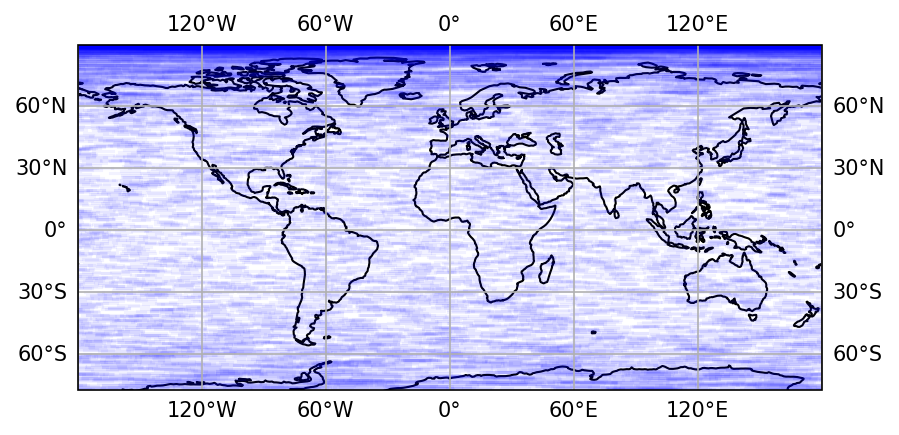

In [10]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": cartopy.crs.PlateCarree()})
fig.set_dpi(150)
for n in range(ds.sizes["trajectory"]):
    ax.plot(
        *ds.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="b", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )
ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    np.min(fieldset.U.grid.lat),
    np.max(fieldset.U.grid.lat),
])
ax.gridlines(draw_labels=True);